In [2]:
!pip3 install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 1.4 MB/s  0:00:061.4 MB/s eta 0:00:01:02
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 1.4 MB/s  0:00:021.3 MB/s eta 0:00:01:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 1.6 MB/s  0:00:02m 1.6 MB/s eta 0:00:01
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib] 6/7 [matplotlib]ow]


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
bird_path = "filtered_new_bird_data.csv"
weather_path = "monthly_weather.csv"
bird = pd.read_csv(bird_path)
weather = pd.read_csv(weather_path)
print(bird.head())
print(weather.head())


Matplotlib is building the font cache; this may take a moment.


  taxonomic_order category          common_name     scientific_name  \
0           32288  species     Asian Rosy-Finch  Leucosticte arctoa   
1           21391  species  Azure-winged Magpie    Cyanopica cyanus   
2           21391  species  Azure-winged Magpie    Cyanopica cyanus   
3           21391  species  Azure-winged Magpie    Cyanopica cyanus   
4           21391  species  Azure-winged Magpie    Cyanopica cyanus   

   observation_count country    state  county  county_code  \
0               80.0   China  Beijing     NaN          NaN   
1               15.0   China  Beijing     NaN          NaN   
2               10.0   China  Beijing     NaN          NaN   
3               70.0   China  Beijing     NaN          NaN   
4                4.0   China  Beijing     NaN          NaN   

                          locality  ...    year  month   day weekday  \
0                         Lingshan  ...  2015.0    1.0   5.0     0.0   
1                       NE Beijing  ...  2015.0    1.0  

/var/folders/xf/dq8k4dv10bl_p4pcqkqk3y580000gp/T/ipykernel_43640/2914417958.py:5: DtypeWarning: Columns (0: taxonomic_order) have mixed types. Specify dtype option on import or set low_memory=False.
  bird = pd.read_csv(bird_path)


In [4]:
print(bird.columns)
print(weather.columns)

Index(['taxonomic_order', 'category', 'common_name', 'scientific_name',
       'observation_count', 'country', 'state', 'county', 'county_code',
       'locality', 'latitude', 'longitude', 'observation_date',
       'time_observations_started', 'observation_type', 'protocol_name',
       'duration_minutes', 'effort_distance_km', 'number_observers',
       'all_species_reported', 'reason', 'presence', 'year', 'month', 'day',
       'weekday', 'dayofyear', 'hour', 'is_weekend', 'migration_season',
       'morning_peak', 'evening_peak'],
      dtype='str')
Index(['year', 'month', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wspd', 'pres',
       'GDD', 'extreme_high', 'extreme_low', 'rain_day', 'strong_wind'],
      dtype='str')


In [7]:
#统一颗粒度
bird["observation_date"] = pd.to_datetime(bird["observation_date"])

bird["year_month"] = bird["observation_date"].dt.to_period("M").dt.to_timestamp()

weather["year_month"] = pd.to_datetime(
    weather["year"].astype(str) + "-" + weather["month"].astype(str) + "-01"
)

In [8]:
#每月总count
bird_monthly = (
    bird.groupby("year_month")["observation_count"]
    .sum()
    .reset_index()
)

bird_monthly.rename(columns={"observation_count": "monthly_observation_count"}, inplace=True)

bird_monthly.head()

,year_month,monthly_observation_count
0,2015-01-01,3692.0
1,2015-02-01,1914.0
2,2015-03-01,8425.0
3,2015-04-01,8714.0
4,2015-05-01,14529.0


In [9]:
#只保留一些环境数据
weather_monthly = weather[["year_month", "tavg", "tmin", "tmax"]].copy()

weather_monthly.head()

,year_month,tavg,tmin,tmax
0,2017-01-01,-2.253846,-7.842308,3.350000
1,2017-02-01,2.466667,-4.225000,8.858333
2,2017-03-01,9.204348,1.895652,15.439130
3,2017-04-01,16.946429,8.757143,23.685714
4,2017-05-01,23.791667,15.345833,30.525000


In [10]:
#合并数据
merged = pd.merge(
    bird_monthly,
    weather_monthly,
    on="year_month",
    how="inner"
)

merged.head()

,year_month,monthly_observation_count,tavg,tmin,tmax
0,2017-01-01,9924.0,-2.253846,-7.842308,3.350000
1,2017-02-01,7563.0,2.466667,-4.225000,8.858333
2,2017-03-01,23703.0,9.204348,1.895652,15.439130
3,2017-04-01,16715.0,16.946429,8.757143,23.685714
4,2017-05-01,21390.0,23.791667,15.345833,30.525000


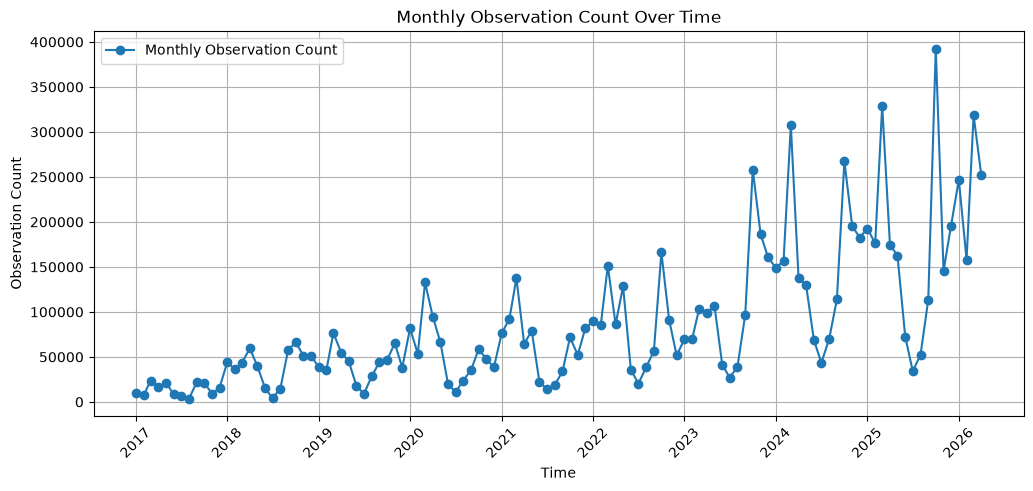

In [12]:
#figure1:observation count change by month
plt.figure(figsize=(12, 5))

plt.plot(
    merged["year_month"],
    merged["monthly_observation_count"],
    marker="o",
    label="Monthly Observation Count"
)

plt.xlabel("Time")
plt.ylabel("Observation Count")
plt.title("Monthly Observation Count Over Time")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

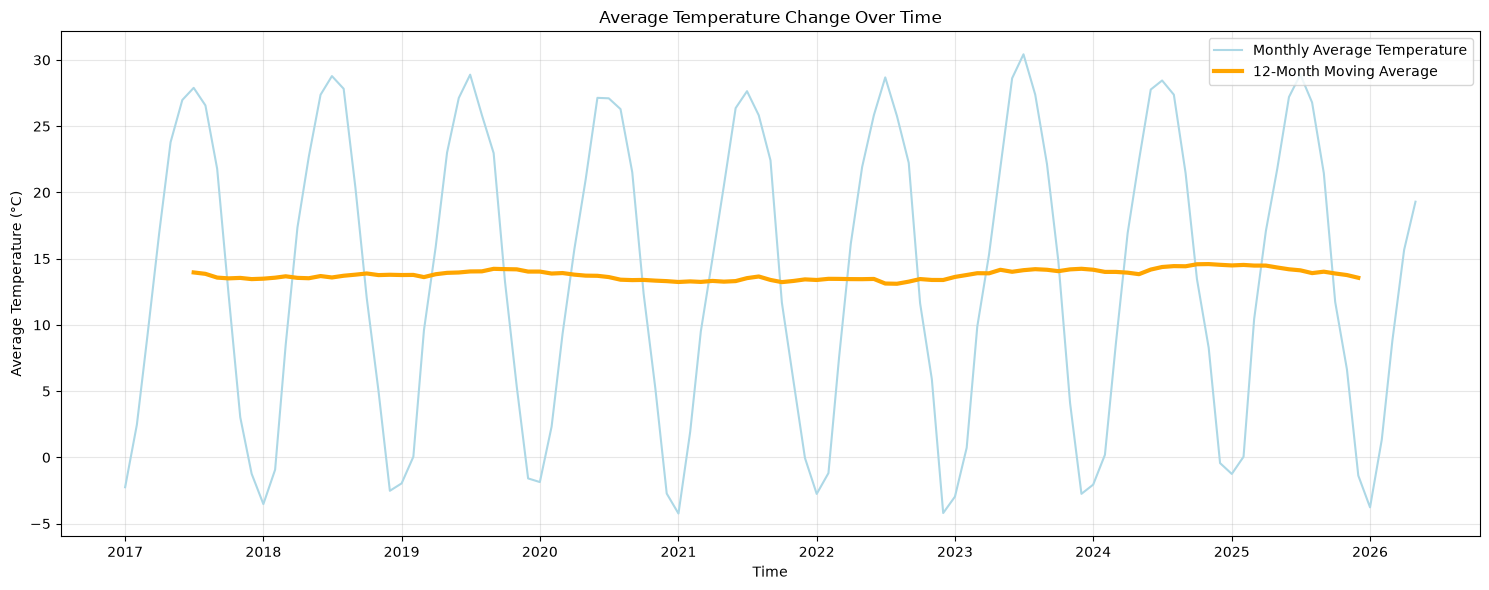

In [60]:
#figure2: temperature change by month
weather_monthly = weather.sort_values("year_month").copy()

weather_monthly["temp_12month"] = (
    weather_monthly["tavg"]
    .rolling(window=12, center=True)
    .mean()
)

plt.figure(figsize=(15,6))

# Month Temperature 
plt.plot(
    weather_monthly["year_month"],
    weather_monthly["tavg"],
    color="lightblue",
    linewidth=1.5,
    alpha=1,
    label="Monthly Average Temperature"
)

# Long-term Trend
plt.plot(
    weather_monthly["year_month"],
    weather_monthly["temp_12month"],
    color="orange",
    linewidth=3,
    label="12-Month Moving Average"
)

plt.xlabel("Time")
plt.ylabel("Average Temperature (°C)")

plt.title("Average Temperature Change Over Time")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [46]:
#standardize
merged["obs_scaled"] = (
    merged["monthly_observation_count"] -
    merged["monthly_observation_count"].mean()
) / merged["monthly_observation_count"].std()

merged["temp_scaled"] = (
    merged["tavg"] -
    merged["tavg"].mean()
) / merged["tavg"].std()

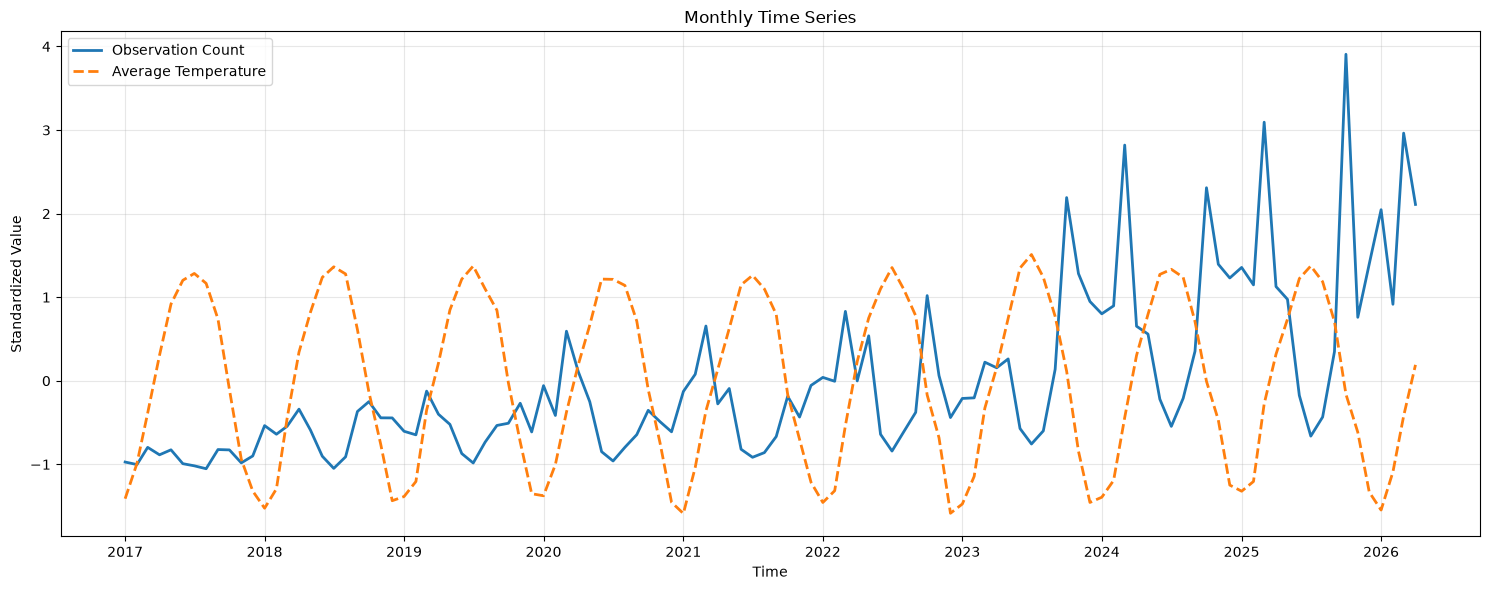

In [34]:
#figure3: monthly overlapping figure of observation count and average temperature 
plt.figure(figsize=(15,6))

plt.plot(
    merged["year_month"],
    merged["obs_scaled"],
    linewidth=2,
    label="Observation Count"
)

plt.plot(
    merged["year_month"],
    merged["temp_scaled"],
    linewidth=2,
    linestyle="--",
    label="Average Temperature"
)

plt.xlabel("Time")
plt.ylabel("Standardized Value")
plt.title("Monthly Time Series")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#setup
merged["obs_12month"] = (
    merged["obs_scaled"]
    .rolling(window=12, center=True)
    .mean()
)

merged["temp_12month"] = (
    merged["temp_scaled"]
    .rolling(window=12, center=True)
    .mean()
)

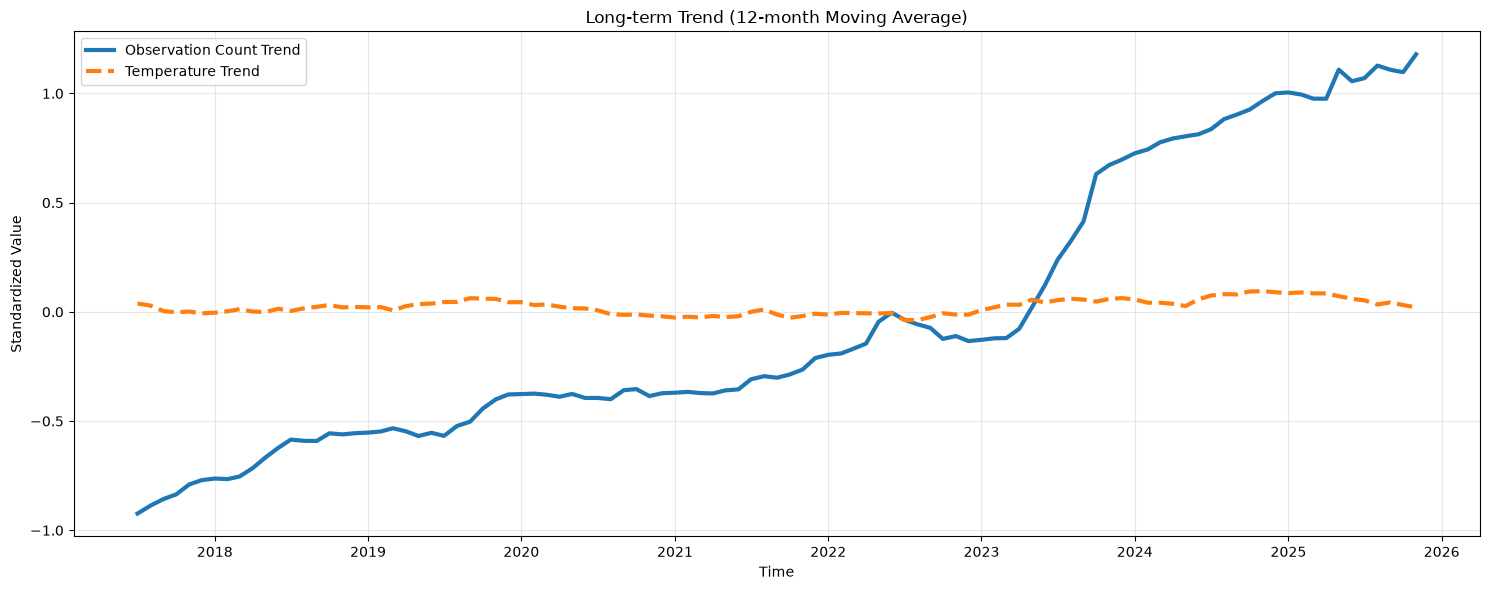

In [35]:
#figure4: overlapping figure of the 3-month trend observation count and average temperature 
plt.figure(figsize=(15,6))

plt.plot(
    merged["year_month"],
    merged["obs_12month"],
    linewidth=3,
    label="Observation Count Trend"
)

plt.plot(
    merged["year_month"],
    merged["temp_12month"],
    linewidth=3,
    linestyle="--",
    label="Temperature Trend"
)

plt.xlabel("Time")
plt.ylabel("Standardized Value")
plt.title("Long-term Trend (12-month Moving Average)")

plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [42]:
corr = merged["monthly_observation_count"].corr(merged["tavg"])
print(f"Monthly correlation between observation count and mean temperature = {corr:.3f}")

Monthly correlation between observation count and mean temperature = -0.306


In [38]:
#setup
merged["year"] = merged["year_month"].dt.year
yearly_compare = (
    merged.groupby("year", as_index=False)
    .agg({
        "monthly_observation_count": "mean",   
        "tavg": "mean"                         
    })
)
yearly_compare["obs_scaled"] = (
    yearly_compare["monthly_observation_count"]
    - yearly_compare["monthly_observation_count"].mean()
) / yearly_compare["monthly_observation_count"].std()

yearly_compare["temp_scaled"] = (
    yearly_compare["tavg"]
    - yearly_compare["tavg"].mean()
) / yearly_compare["tavg"].std()


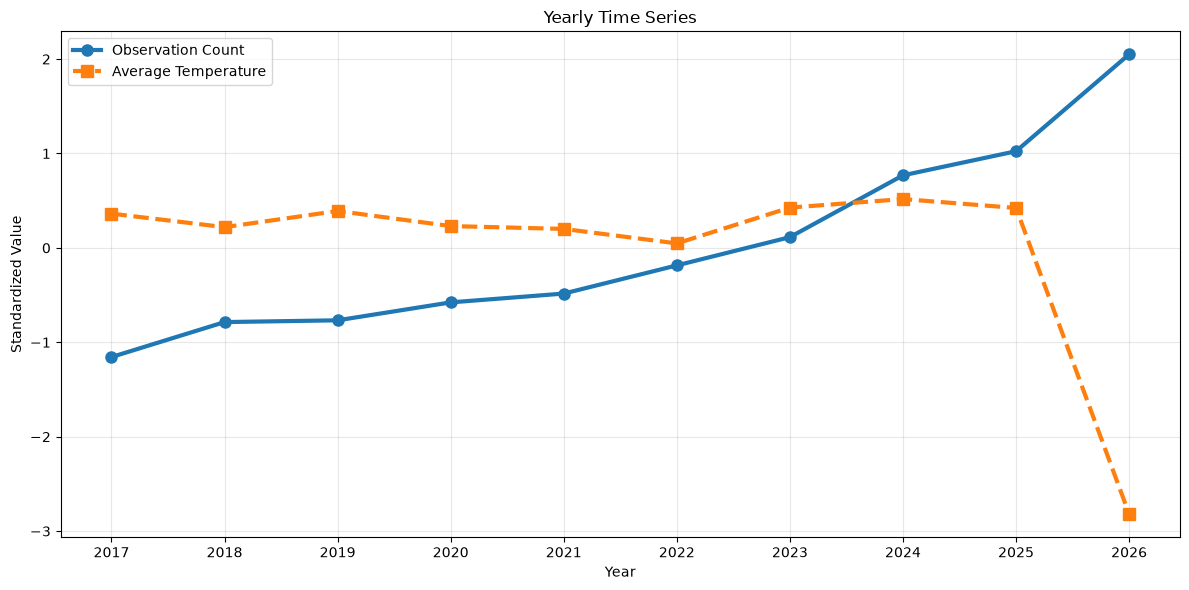

In [39]:
#figure5: yearly overlapping figure of observation count and average temperature 
plt.figure(figsize=(12,6))

plt.plot(
    yearly_compare["year"],
    yearly_compare["obs_scaled"],
    marker="o",
    linewidth=3,
    markersize=8,
    label="Observation Count"
)

plt.plot(
    yearly_compare["year"],
    yearly_compare["temp_scaled"],
    marker="s",
    linewidth=3,
    linestyle="--",
    markersize=8,
    label="Average Temperature"
)

plt.xlabel("Year")
plt.ylabel("Standardized Value")

plt.title("Yearly Time Series")

plt.xticks(yearly_compare["year"])

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

In [41]:
corr_year = yearly_compare["monthly_observation_count"].corr(
    yearly_compare["tavg"]
)

print(f"Yearly Correlation between observation count and mean temperature = {corr_year:.3f}")

Yearly Correlation between observation count and mean temperature = -0.670
